## Topic Analysis of Reddit Discussions about Limb Loss and Prosthetic Rehabilitation

**Team:**
* Sareena Gurung
* Prateek Grover

**Course:** DAAN 897– Deep Learning (Summer, 2026)

### Problem Statement
* This project aims to investigate the technical nuances and feasibility of developing a limb loss support chatbot from online PwLL forum data, with a focus on assessing feasibility and comparing clustering with manual labeling.
    * Aim 1: To what extent can unsupervised text clustering reduce human annotation required for developing a limb loss support chatbot?
    * Aim 2: Which types of questions or themes are the easiest and most difficult to identify?
    
    
* **Keywords:** Reddit, amputation, prosthetics, rehabilitation
	

### Data Collection
* Source(url): https://www.reddit.com/
* Short Description : The data set consists of manually scraped comments related to amputation and prosthetics from Reddit forums

* Keywords: Reddit, amputation, prosthetics, rehabilitation

### Required packages

* Install required packages


In [ ]:
%pip install pandas numpy matplotlib scikit-learn sentence-transformers datasets transformers accelerate

### Data Preprocessing

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)


In [ ]:
# set path and import file
DATA_PATH = Path.home() / "Downloads"

file_path = DATA_PATH / "AMA_subreddit_questions_cleaned(cleaned_data).csv"

df = pd.read_csv(file_path, encoding="cp1252")

print(df.shape)

print(df.columns)

df.head()

(248, 14)
Index(['document_id', 'original_text', 'cleaned_text', 'reviewer_sentiment',
       'reviewer_theme', 'word_count', 'character_count', 'manual_label',
       'cluster_id', 'cluster_label', 'predicted_label',
       'prediction_confidence', 'validation_status', 'validation_notes'],
      dtype='str')


,document_id,original_text,cleaned_text,reviewer_sentiment,reviewer_theme,word_count,character_count,manual_label,cluster_id,cluster_label,predicted_label,prediction_confidence,validation_status,validation_notes
0,COMMENT_0001,Were your arms and leg amputated right at the ...,Were your arms and leg amputated right at the ...,Mixed/Neutral,Cause / Surgery,47,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,COMMENT_0002,How has this impacted your juggling career?,How has this impacted your juggling career?,Negative,Physical health and daily function,7,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,COMMENT_0003,That’s recent. How are you coping with the dra...,That’s recent. How are you coping with the dra...,Positive,Mental health and adjustment,10,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,COMMENT_0004,Any potential for some badass cybernetics?,Any potential for some badass cybernetics?,Mixed/Neutral,Device,6,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,COMMENT_0005,Do you plan on finding someone with only their...,Do you plan on finding someone with only their...,Negative,Mental health and adjustment,24,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# check missing
print(df.isnull().sum())

# statistics
df["word_count"] = df["cleaned_text"].str.split().str.len()

df["word_count"].describe()

document_id                0
original_text              0
cleaned_text               0
reviewer_sentiment        48
reviewer_theme            48
word_count                 0
character_count            0
manual_label             248
cluster_id                 0
cluster_label            248
predicted_label          248
prediction_confidence    248
validation_status        248
validation_notes         248
dtype: int64


count    248.000000
mean      21.044355
std       18.542490
min        3.000000
25%        9.000000
50%       14.000000
75%       27.000000
max      111.000000
Name: word_count, dtype: float64

In [ ]:
# check skewness
print(f"skewness: {df['word_count'].skew()}")

skewness: 2.178356615119579


In [ ]:
# check outliers
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["word_count"] < lower) | (df["word_count"] > upper)]

print(len(outliers))

16


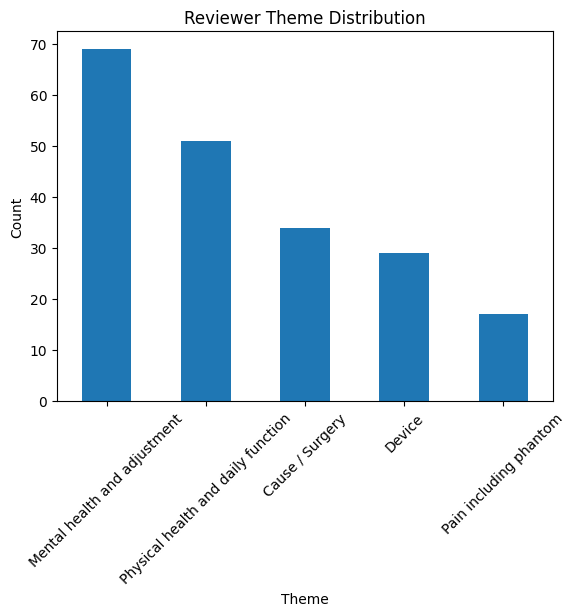

In [ ]:
# check reviewer theme distribution
df["reviewer_theme"].value_counts().plot(
    kind="bar"
)
plt.title("Reviewer Theme Distribution")
plt.xlabel("Theme")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Methodology

1. Explan your Deep Learning process / methodology

2.
 * Model 1
    * SBERT + K-means to determine question themes
 
 * Model 2
    * DistilBERT classify themes
 
 
 
3. **Keywords:** natural language processing, clustering, sentence embedding, classification

### Model Fitting and Validation

1. model 1 
    - Normalized embeddings
    - K-means to group
    - Clusters tested
    - Selected k=7
2. model 2
    - 200 manually labeled comments
    - Five themes for classification
    - DistilBERT tokenizer 

# Unsupervised Learning

In [13]:
# initialize the sentence transformer model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [14]:
# embedd the comments

texts = df["cleaned_text"].tolist()

embeddings = model.encode(texts)

print(embeddings.shape)

(248, 384)


In [15]:
# Normalize the embeddings
embeddings_normalized = normalize(embeddings)

print(embeddings_normalized.shape)

(248, 384)


In [16]:
# evaluate silhouette scores for different values of k
silhouette_results = []

for k in range(2, 16):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    predicted_labels = kmeans.fit_predict(embeddings_normalized)
    
    score = silhouette_score(
        embeddings_normalized,
        predicted_labels
    )
    
    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

    print(
        f"For n_clusters = {k} "
        f"The average silhouetter_score is : {score}"
    )

For n_clusters = 2 The average silhouetter_score is : 0.06265421956777573
For n_clusters = 3 The average silhouetter_score is : 0.06160477548837662
For n_clusters = 4 The average silhouetter_score is : 0.05971119552850723
For n_clusters = 5 The average silhouetter_score is : 0.06039899215102196
For n_clusters = 6 The average silhouetter_score is : 0.059153877198696136
For n_clusters = 7 The average silhouetter_score is : 0.06200256198644638
For n_clusters = 8 The average silhouetter_score is : 0.05556466802954674
For n_clusters = 9 The average silhouetter_score is : 0.05540403351187706
For n_clusters = 10 The average silhouetter_score is : 0.054797474294900894
For n_clusters = 11 The average silhouetter_score is : 0.05536241829395294
For n_clusters = 12 The average silhouetter_score is : 0.05394382402300835
For n_clusters = 13 The average silhouetter_score is : 0.05390850082039833
For n_clusters = 14 The average silhouetter_score is : 0.05062171071767807
For n_clusters = 15 The average

In [17]:
# compare k = 2, 3, 5, 7

k_values = [2, 3, 5, 7]

cluster_size_results = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(
        embeddings_normalized
    )

    cluster_sizes = pd.Series(
        cluster_labels
    ).value_counts().sort_index()

    print(f"\nCluster sizes for k = {k}")
    print(cluster_sizes)

    for cluster_id, size in cluster_sizes.items():

        cluster_size_results.append({
            "k": k,
            "cluster_id": cluster_id,
            "number_of_comments": size
        })

cluster_size_df = pd.DataFrame(
    cluster_size_results
)

print(cluster_size_df)


Cluster sizes for k = 2
0     96
1    152
Name: count, dtype: int64

Cluster sizes for k = 3
0     73
1     73
2    102
Name: count, dtype: int64

Cluster sizes for k = 5
0    61
1    56
2    47
3    53
4    31
Name: count, dtype: int64

Cluster sizes for k = 7
0    40
1    34
2    44
3    27
4    44
5    24
6    35
Name: count, dtype: int64
    k  cluster_id  number_of_comments
0   2           0                  96
1   2           1                 152
2   3           0                  73
3   3           1                  73
4   3           2                 102
5   5           0                  61
6   5           1                  56
7   5           2                  47
8   5           3                  53
9   5           4                  31
10  7           0                  40
11  7           1                  34
12  7           2                  44
13  7           3                  27
14  7           4                  44
15  7           5                  24
16  7    

In [18]:
# fit the final KMeans model with the chosen number of clusters (k=7)
final_kmeans = KMeans(
    n_clusters=7,
    random_state=42
)

df["cluster_id"] = final_kmeans.fit_predict(
    embeddings_normalized
)

In [ ]:
# feature extraction
vectorizer = TfidfVectorizer(
    stop_words="english",
)

Xtfidf = vectorizer.fit_transform(df["cleaned_text"])

feature_names = np.array(
    vectorizer.get_feature_names_out()
)

### Model Evaluation 

In [20]:
# top terms per cluster
final_k = 7

cluster_centroids = []

for i in range(final_k):
    cluster_docs = Xtfidf[cluster_labels == i]
    centroid = np.asarray(
        cluster_docs.mean(axis=0)
    ).flatten()

    cluster_centroids.append(centroid)

cluster_centroids = np.array(cluster_centroids)

# order terms by importance
order_centroids = cluster_centroids.argsort()[:, ::-1]

for i in range(final_k):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{feature_names[ind]} ", end="")
    print()

Cluster 0: accident did happened happen like shock recovery reaction caused waking 
Cluster 1: daily routine doing career life want hobby like going things 
Cluster 2: people help life live support new like friends feel coping 
Cluster 3: typing eat type control use excercise write toes situation sleep 
Cluster 4: did amputated amputation leg limbs arms life amputee lost like 
Cluster 5: pain phantom feel pains experienced ghost limb itch meds stump 
Cluster 6: prosthetics prosthetic leg plan use getting wheelchair option future ve 


In [21]:
# assign cluster names
cluster_names = {
    0: "Accident and Recovery",
    1: "Daily Life",
    2: "Social Support and Coping",
    3: "Daily Tasks",
    4: "Amputation and Limb Loss",
    5: "Phantom Limb Pain",
    6: "Prosthetics and Mobility"
}

In [22]:
cluster_review = df.copy()

# add cluster labels
cluster_review["cluster"] = cluster_labels

# add cluster names
cluster_review["cluster_theme"] = cluster_review["cluster"].map(cluster_names)

# keep relevant columns
cluster_review = cluster_review[
    ["cluster", "cluster_theme", "cleaned_text", "reviewer_theme", "reviewer_sentiment"]
]

# sort by cluster value
cluster_review = cluster_review.sort_values(["cluster", "cleaned_text"])

# export to CSV
output_file = DATA_PATH / "cluster_review.csv"
cluster_review.to_csv(output_file, index=False)

print("cluster_review.csv saved")

cluster_review.csv saved


# Supervised

In [ ]:
# create a df with only rows that have a reviewer theme
super_df = df.dropna(subset=["reviewer_theme"]).copy()

print(df["reviewer_theme"].isna().sum())

# check the distribution of reviewer themes
print(
    super_df["reviewer_theme"]
    .value_counts()
)

48
reviewer_theme
Mental health and adjustment          69
Physical health and daily function    51
Cause / Surgery                       34
Device                                29
Pain including phantom                17
Name: count, dtype: int64


In [28]:
# encode the reviewer themes as labels
label_encoder = LabelEncoder()

super_df["label"] = label_encoder.fit_transform(super_df["reviewer_theme"])

print(label_encoder.classes_)

['Cause / Surgery' 'Device' 'Mental health and adjustment'
 'Pain including phantom' 'Physical health and daily function']


In [29]:
# train test split
train_df, test_df = train_test_split(
    super_df,
    test_size=0.2,
    random_state=42,
    stratify=super_df["label"]
)

In [30]:
# initialize the tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# keep only the relevant columns
train_df = train_df[["cleaned_text", "label"]]
test_df = test_df[["cleaned_text", "label"]]

# convert the dataframes to Hugging Face datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# define the tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["cleaned_text"],
        truncation=True
    )

# tokenize the datasets
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [39]:
# load the pre-trained model for sequence classification
model_transformer = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=len(label_encoder.classes_)
)

# padding the inputs to the same length for batching
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="macro")
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

# define the training arguments
training_args = TrainingArguments(
    output_dir = str(DATA_PATH / "distilbert_results"),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=8,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    seed = 42,
    report_to="none"
)

# define trainer
trainer = Trainer(
    model=model_transformer,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# train model
trainer.train()

# evaluate
results = trainer.evaluate()
print(results)

# save model
trainer.save_model(str(DATA_PATH / "distilbert_results" / "final_model"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/sareena/tfenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init_

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,1.481246,0.350000,0.103704,0.070000,0.200000
2,No log,1.383402,0.375000,0.141026,0.173684,0.220000
3,No log,1.252820,0.475000,0.310375,0.327778,0.337143
4,No log,1.115492,0.500000,0.343161,0.338986,0.371429
5,No log,1.017896,0.625000,0.589448,0.765079,0.553333
6,No log,0.968611,0.725000,0.694978,0.813690,0.660000
7,No log,0.911020,0.750000,0.765057,0.823939,0.735238
8,No log,0.896438,0.775000,0.782597,0.840476,0.755238


/Users/sareena/tfenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sareena/tfenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/sareena/tfenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sareena/tfenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memor

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
No log,0.896438,8,0.775000,0.782597,0.840476,0.755238


{'eval_loss': 0.8964382410049438, 'eval_accuracy': 0.775, 'eval_f1': 0.7825974025974027, 'eval_precision': 0.8404761904761905, 'eval_recall': 0.7552380952380953}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Model Evaluation 

In [ ]:
# make predictions on the test set
prediction_output = trainer.predict(tokenized_test)

y_pred = np.argmax(
    prediction_output.predictions,
    axis=-1
)

y_true = prediction_output.label_ids

# print classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
    )
)

/Users/sareena/tfenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


                                    precision    recall  f1-score   support

                   Cause / Surgery       0.75      0.86      0.80         7
                            Device       1.00      0.67      0.80         6
      Mental health and adjustment       0.79      0.79      0.79        14
            Pain including phantom       1.00      0.67      0.80         3
Physical health and daily function       0.67      0.80      0.73        10

                          accuracy                           0.78        40
                         macro avg       0.84      0.76      0.78        40
                      weighted avg       0.80      0.78      0.78        40



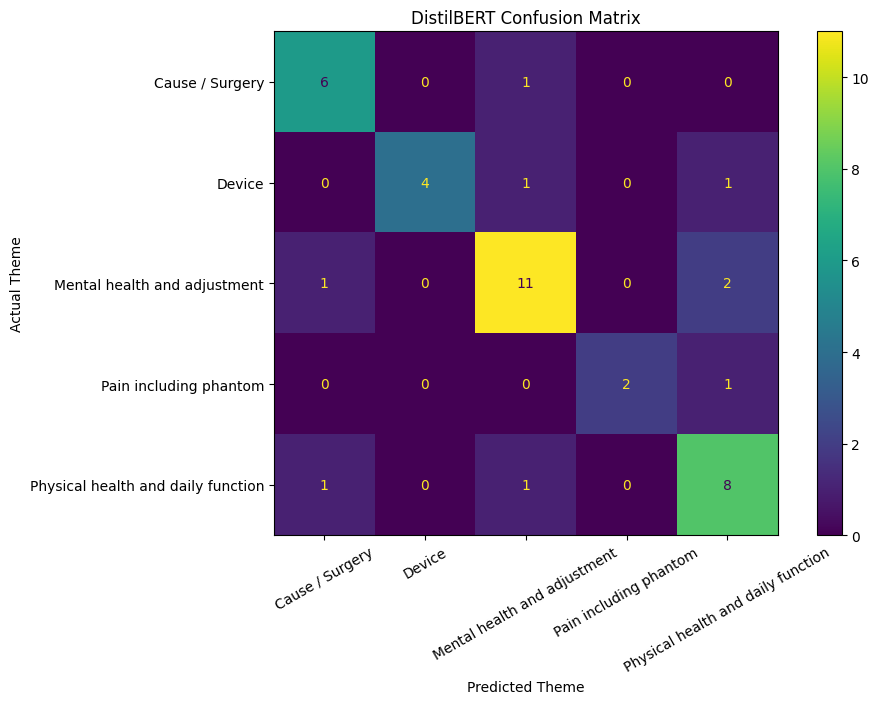

In [ ]:
# confusion matrix
cm = confusion_matrix(y_true,y_pred)

# display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    cmap = "viridis",
    xticks_rotation = 30,
    values_format = "d",
    ax = ax
)


plt.xlabel("Predicted Theme")
plt.ylabel("Actual Theme")
plt.title("DistilBERT Confusion Matrix")

plt.subplots_adjust(bottom=0.25)

plt.show()

### Issues / Improvements
1. Dataset is very small (~250 comments)
2. There is class imbalance for some themes
3. Overlapping themes


###  References
   - https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
   - https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
	- https://medium.com/thenextlayer/building-a-text-classification-model-using-distilbert-703c1409696c
   - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

### Credits

- If you use and/or adapt your code from existing projects, you must provide links and acknowldge the authors. Keep in mind that all documents in your projects and code will be check against the official plagiarism detection tool used by Penn State ([Turnitin](https://turnitin.psu.edu))

> *This code is based on .... (if any)*